In [157]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import math
from tqdm import tqdm
from scipy.spatial import distance
import seaborn as sns
from scipy.linalg import hadamard
from sklearn.metrics import r2_score
import pandas as pd
import datetime
import time
import string

In [158]:
# converts an index to a Hamming graph position
def ind2sub(ind,K,L):
    if ind == 0:
        return np.zeros(L, dtype=int)
    else:
        mysub = int(np.base_repr(ind,K))
        digits = int(math.log10(mysub))+1
        mysub_str = '0'*(L-digits) + str(mysub)
        unjoined = list(mysub_str)
        return np.array([int(i) for i in unjoined])

# converts a Hamming graph position to an index
def sub2ind(sub,K,L):
    return int(sum(np.multiply(sub,[K**(L-i-1) for i in range(L)])))

In [159]:
df = pd.read_csv('./yeast_data/raw_data.csv',delimiter='\t')

## YPD

In [160]:
df_ypd = df[df['Population'] == 'YPD']
freq_timeseries = df_ypd.iloc[:,6:105].to_numpy()

In [161]:
df_ypd

,Population,Barcodes,EvolutionFitness(percent),EvolutionFitnessConfidenceInterval(percent),BarcodingFitness(per barcoding procedure),BarcodingFitnessConfidenceInterval(per barcoding procedure),Frequency(t=1.0),Frequency(t=1.10),Frequency(t=1.20),Frequency(t=1.30),...,Frequency(t=10.10),Frequency(t=10.20),Frequency(t=10.30),Frequency(t=10.40),Frequency(t=10.50),Frequency(t=10.60),Frequency(t=10.70),Frequency(t=10.80),Frequency(t=10.90),Frequency(t=10.100)
0,YPD,ancestor,0.00,"-0.0500000000,0.0000000000",0.000,"-0.0350000000,0.0300000000",0.999669,0.999674,0.999745,0.999706,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,YPD,CCTGGAGCAGTCTAAT,0.75,"0.5000000000,0.9500000000",0.230,"-0.0350000000,0.4600000000",0.000040,0.000033,0.000027,0.000034,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,YPD,ACGAGGCGTGTAATCA,-0.10,"-0.3000000000,0.0500000000",1.130,"0.9600000000,1.2900000000",0.000035,0.000069,0.000038,0.000074,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,YPD,GTGCCTAGACCAACTT,0.00,"-0.2000000000,0.2000000000",1.095,"0.9000000000,1.2700000000",0.000175,0.000147,0.000148,0.000100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,YPD,AGCTATACCCCAACAA,0.65,"0.5500000000,0.7500000000",0.455,"0.3200000000,0.5750000000",0.000082,0.000076,0.000042,0.000086,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,YPD,GCATCGTACACCGGAT_GATCCACAGCCTGTAT_ATCAGTAAACTT...,4.00,"3.2500000000,4.7000000000",0.890,"-0.7550000000,1.8050000000",0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,YPD,TCTAAGCGTATTGGTC_ATCCAGCGCTTGGACG_AGATGAACCGGC...,3.40,"3.1000000000,3.7500000000",1.685,"1.1950000000,2.0750000000",0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70,YPD,TACAGGGGATGAAGCT_GTTGATTGGACGGATG_ATTACATATGCA...,2.00,"1.4000000000,2.5500000000",2.985,"2.4700000000,3.3950000000",0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71,YPD,TACAGGGGATGAAGCT_GTTGATTGGACGGATG_ATTACATATGCA...,3.65,"2.9500000000,4.2500000000",2.570,"1.4850000000,3.2750000000",0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


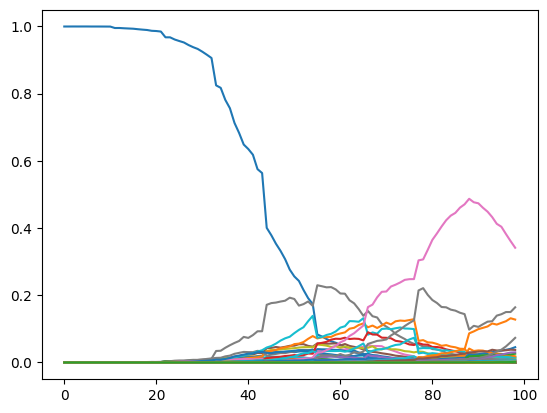

In [162]:
plt.plot(freq_timeseries.T)
plt.show()

In [163]:
F_real = (100*df_ypd['EvolutionFitness(percent)'].to_numpy() + df_ypd['BarcodingFitness(per barcoding procedure)'].to_numpy())/200
# F_real = F_real - np.min(F_real) + 1
np.savetxt('yeast_data/ypd_F_real.csv',F_real,delimiter=',')

In [164]:
np.savetxt('yeast_data/ypd_freq_timeseries_T99.csv',freq_timeseries,delimiter=',')

In [165]:
np.savetxt('yeast_data/ypd_M.csv',-np.eye(freq_timeseries.shape[0]),delimiter=',')

(array([ 3., 11., 24.,  6.,  8.,  7.,  7.,  3.,  2.,  2.]),
 array([-0.04435,  0.19087,  0.42609,  0.66131,  0.89653,  1.13175,
         1.36697,  1.60219,  1.83741,  2.07263,  2.30785]),
 <BarContainer object of 10 artists>)

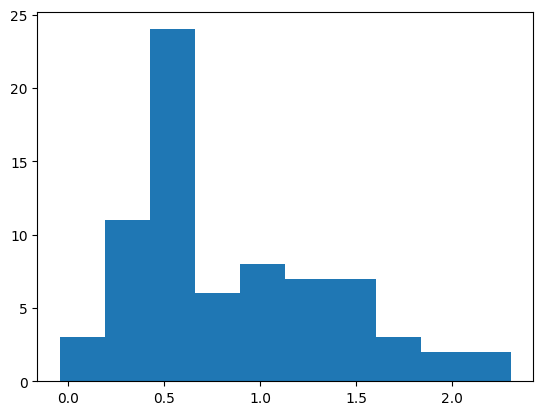

In [166]:
plt.hist(F_real)

# YPA

In [167]:
df_ypa = df[df['Population'] == 'YPA']
freq_timeseries = df_ypa.iloc[:,6:].to_numpy()

In [168]:
df_ypa

,Population,Barcodes,EvolutionFitness(percent),EvolutionFitnessConfidenceInterval(percent),BarcodingFitness(per barcoding procedure),BarcodingFitnessConfidenceInterval(per barcoding procedure),Frequency(t=1.0),Frequency(t=1.10),Frequency(t=1.20),Frequency(t=1.30),...,Frequency(t=10.10),Frequency(t=10.20),Frequency(t=10.30),Frequency(t=10.40),Frequency(t=10.50),Frequency(t=10.60),Frequency(t=10.70),Frequency(t=10.80),Frequency(t=10.90),Frequency(t=10.100)
73,YPA,ancestor,0.00,"0.0000000000,0.0000000000",0.000,"-0.0300000000,0.0350000000",0.999023,0.998962,0.998963,0.998894,...,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000,-0.000000
74,YPA,AGTAAGACCTCGGGCC,1.25,"1.1500000000,1.3000000000",0.555,"0.4800000000,0.6250000000",0.000240,0.000237,0.000172,0.000179,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75,YPA,CCACGCGCGGTACGTC,1.70,"1.6500000000,1.7500000000",0.210,"0.1450000000,0.2750000000",0.000003,0.000005,0.000005,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
76,YPA,AAACTTATGCACTCAC,0.40,"0.1000000000,0.6500000000",0.520,"0.2800000000,0.7350000000",0.000095,0.000112,0.000126,0.000133,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
77,YPA,TACCCGATGGCGAAGC,1.10,"0.8500000000,1.3500000000",0.790,"0.6100000000,0.9550000000",0.000078,0.000127,0.000103,0.000147,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,YPA,CGCGGTGGAACGGAGG_CGCAACATGTAAACTT_AACGATGATACG...,6.55,"5.2000000000,7.8500000000",-0.150,"-2.6000000000,0.9200000000",0.000000,0.000000,0.000000,0.000000,...,0.000065,0.000048,0.000051,0.000021,0.000009,0.000052,0.000023,0.000024,0.000022,0.000020
194,YPA,TCTAGCGCGGCCGAAT_CTATGAGGTAGAAACA_CCGGAAAGAGTA...,7.30,"6.4000000000,8.2000000000",-0.805,"-2.8100000000,0.1650000000",0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
195,YPA,TCCATTGAGAACAACT_TGCACACCCATGAGTA_GGTTGCAAGCAT...,7.50,"6.7000000000,8.2500000000",4.760,"4.0500000000,5.0000000000",0.000000,0.000000,0.000000,0.000000,...,0.000821,0.000947,0.001125,0.000942,0.001021,0.000876,0.001021,0.001086,0.001112,0.000836
196,YPA,TCCATTGAGAACAACT_TGCACACCCATGAGTA_GGTTGCAAGCAT...,8.65,"7.8500000000,9.4000000000",3.070,"2.0450000000,3.7450000000",0.000000,0.000000,0.000000,0.000000,...,0.000816,0.000737,0.000721,0.000747,0.000747,0.000778,0.000742,0.000827,0.000854,0.000836


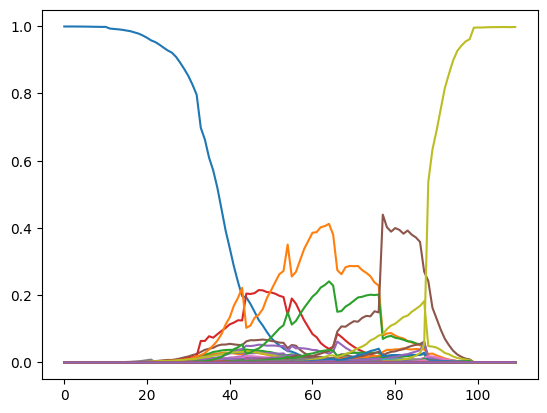

In [169]:
plt.plot(freq_timeseries.T)
plt.show()

In [170]:
F_real = (100*df_ypa['EvolutionFitness(percent)'].to_numpy() + df_ypa['BarcodingFitness(per barcoding procedure)'].to_numpy())/200
# F_real = F_real - np.min(F_real) + 1
np.savetxt('yeast_data/ypa_F_real.csv',F_real,delimiter=',')

In [171]:
freq_timeseries.shape

(125, 110)

In [172]:
np.savetxt('yeast_data/ypa_freq_timeseries_T110.csv',freq_timeseries,delimiter=',')

In [173]:
np.savetxt('yeast_data/ypa_M.csv',-np.eye(freq_timeseries.shape[0]),delimiter=',')

(array([ 7.,  6., 32., 18., 11., 23., 17.,  5.,  2.,  4.]),
 array([-0.39265  ,  0.0855175,  0.563685 ,  1.0418525,  1.52002  ,
         1.9981875,  2.476355 ,  2.9545225,  3.43269  ,  3.9108575,
         4.389025 ]),
 <BarContainer object of 10 artists>)

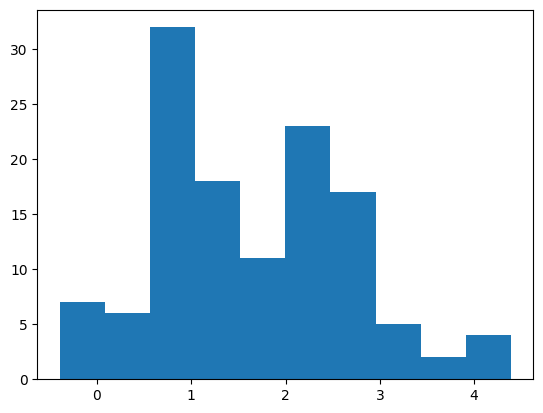

In [174]:
plt.hist(F_real)